- Within this mini project, a linear algebra model is constructed to predict house prices based on their sizes, assuming the error vector is not zero, though the orthogonality principle, which guarantees minimum distance between different spans / planes herein, does not overrule even if the error vector is null.
- Target --> Price
- Features(s) --> Size (+ intercept)
- Linear normal equation is solved both by
    - taking the inverse of the coefficient matrix, and
    - finding the reduced row echelon form of the solution matrix.

# Import

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc("axes.spines", top=False, right=False)
plt.style.use("ggplot")

# Load Data

In [2]:
df = pd.read_csv("housing_data.csv")

In [3]:
df = df.rename(columns={"s":"size"})

In [4]:
df

,Intercept coef,size,price
0,1,479.75,154282.128
1,1,525.81,168047.264
2,1,549.69,171795.240
3,1,620.82,175716.480
4,1,681.07,180307.216
...,...,...,...
95,1,1300.96,444192.008
96,1,1496.36,454512.760
97,1,1275.46,458674.256
98,1,1842.51,494778.992


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Intercept coef  100 non-null    int64  
 1   size            100 non-null    float64
 2   price           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


# Transfer df into numpy matrice / vector

In [6]:
A = np.column_stack([df["Intercept coef"], df["size"]])

In [7]:
b = np.column_stack([df.price])

# Solve by Normal Equation --> Inverse

1. Equation (raw)--> $y = ax$ --> $y = \beta_1 x$
2. Most software packages add constant / intercept to respond to possible base value
3. Equation with intercept --> $y = ax + b$ --> $y = \beta_0 + \beta_1x$
4. X is the predictor, size vector and y is the target, price vector
5. We need to assume the equation as $y = \beta_0 c + \beta_1x$ where c is a "ones" vector to construct the A matrix
6. Linear equation is $Ax = b$ --> where A is comprised of c and x vectors --> 100 x 2 and x is comprised of c and x
7. Since this is a regression, $e = b - Ax$ is the error vector
8. Minimized error by least squares of errors could be guaranteed by the shortest path between actual y (price) values and the A plane.
9. This means
    - $A^T.e = 0$
    - $A^T.(b-Ax) = 0$
    - $A^T.b - A^T.A.x = 0$
    - $A^T.A.x = A^T.b$
    - $(A^T.A)^{-1}.(A^T.A).x =  (A^T.A)^{-1}.A^T.b$ and finally,

$x=(A^T.A)^{-1}.A^T.b$

In [8]:
beta_0, beta_1 = np.linalg.multi_dot((np.linalg.inv(np.dot(A.T, A)), A.T, b)) 

In [9]:
beta_0

array([101912.60180123])

In [10]:
beta_1

array([223.17874259])

price = 101912 + 223 * size 

If size 3000 then the price is 771448.

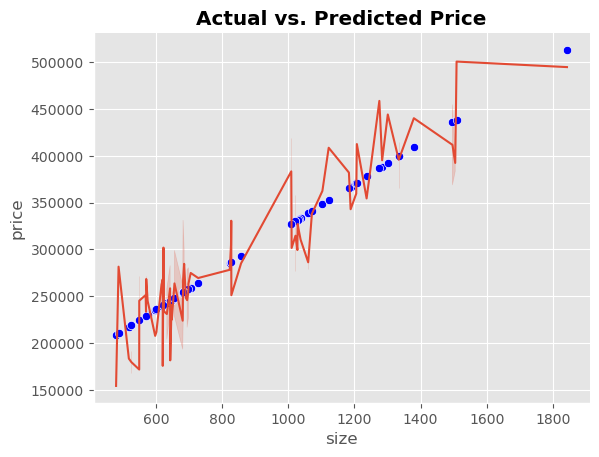

In [11]:
fig, ax = plt.subplots()
sns.lineplot(data=df, x="size", y="price", ax=ax)
sns.scatterplot(x=df["size"], y=df["size"].apply(lambda cell: beta_0[0] + beta_1[0]*cell), ax=ax, color="blue")
plt.title("Actual vs. Predicted Price", fontdict={"weight": "bold"});

# Solve by Normal Equation --> RREF

$[A^T.A | A^T.b]$

In [12]:
import sympy as sy

In [13]:
augmented = sy.Matrix(np.column_stack((np.dot(A.T, A), np.dot(A.T, b))))

In [14]:
rref, pivots = augmented.rref()

In [15]:
rref

Matrix([
[1, 0,  101912.60180123],
[0, 1, 223.178742594606]])

In [16]:
pivots

(0, 1)

In [17]:
beta_0, beta_1 = rref[:,-1]

In [18]:
beta_0

101912.601801230

In [19]:
beta_1

223.178742594606

The same result --> price = 101912 + 223 * size 